# 8. In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

In [168]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## (a) Create a random number generator and use its normal() method to generate a predictor X of length n = 100, as well as a noise vector ϵ of length n = 100.

In [169]:
n = 100
np.random.seed(42)

X = np.random.normal(loc=0, scale=1, size=n)
epsilon = np.random.normal(loc=0, scale=1, size=n)

X_data = pd.DataFrame({f"X{i}": X**i for i in range(1, 11)})
X_data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,0.496714,0.246725,0.122552,0.060873,0.030237,0.015019,7.460119e-03,3.705547e-03,1.840597e-03,9.142508e-04
1,-0.138264,0.019117,-0.002643,0.000365,-0.000051,0.000007,-9.659851e-07,1.335613e-07,-1.846675e-08,2.553293e-09
2,0.647689,0.419500,0.271706,0.175981,0.113981,0.073824,4.781493e-02,3.096918e-02,2.005838e-02,1.299158e-02
3,1.523030,2.319620,3.532850,5.380637,8.194870,12.481032,1.900898e+01,2.895125e+01,4.409362e+01,6.715590e+01
4,-0.234153,0.054828,-0.012838,0.003006,-0.000704,0.000165,-3.859250e-05,9.036565e-06,-2.115942e-06,4.954550e-07


## (b) Generate a response vector Y of length n = 100 according to the model
$$Y = β0 + β1X + β2X2 + β3X3 + ϵ$$
## , where β0, β1, β2, and β3 are constants of your choice.


In [170]:
beta_0 = 5.0
beta_1 = 1.5
beta_2 = -2.0
beta_3 = 0.5

# 生成 Y
Y = beta_0 + beta_1 * X + beta_2 * (X**2) + beta_3 * (X**3) + epsilon

## (c) Use forward stepwise selection in order to select a model contain￾ing the predictors $X, X2, . . . , X10.$ What is the model obtained according to Cp? Report the coefcients of the model obtained.

In [171]:
X_vars = X_data.columns.tolist()

X_full = sm.add_constant(X_data)
full_model = sm.OLS(Y, X_full).fit()
sigma_hat_sq = full_model.mse_resid

def calculate_cp(model_features, X_data, Y, sigma_hat_sq, n):
    if not model_features:
        RSS = np.sum((Y - Y.mean())**2)
    else:
        X_current = sm.add_constant(X_data[model_features])
        model = sm.OLS(Y, X_current).fit()
        RSS = model.ssr

    p = len(model_features) + 1
    cp = (RSS / sigma_hat_sq) - (n - 2 * p)
    return cp, p, RSS

In [172]:
print("向前逐步選擇：\n")

selected_features = []
remaining_features = list(X_vars)
model_results = []

for i in range(1, len(X_vars) + 1):
    best_rss_in_step = float('inf')
    best_feature = None

    for feature in remaining_features:
        current_features = selected_features + [feature]

        X_current = sm.add_constant(X_data[current_features])
        model = sm.OLS(Y, X_current).fit()

        if model.ssr < best_rss_in_step:
            best_rss_in_step = model.ssr
            best_feature = feature

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    cp, p, rss = calculate_cp(selected_features, X_data, Y, sigma_hat_sq, n)

    X_current = sm.add_constant(X_data[selected_features])
    model = sm.OLS(Y, X_current).fit()

    model_results.append({'i': i, 'Cp': cp, 'features': list(selected_features)})
    print(f"Step {i}: Added {best_feature}, Cp = {cp:.4f}\n{selected_features}")

results_df_f = pd.DataFrame(model_results)
best_result_f = results_df_f.loc[results_df_f['Cp'].idxmin()]

print(f"\n\n最佳變數組合 (by Cp): {best_result_f['features']}（最低 Cp: {best_result_f['Cp']:.4f}）")

best_features_f = best_result_f['features']
X_best_f = sm.add_constant(X_data[best_features_f])
final_forward_model = sm.OLS(Y, X_best_f).fit()
print(final_forward_model.summary().tables[1])

向前逐步選擇：

Step 1: Added X3, Cp = 312.5186
['X3']
Step 2: Added X2, Cp = 56.3564
['X3', 'X2']
Step 3: Added X1, Cp = 4.2647
['X3', 'X2', 'X1']
Step 4: Added X10, Cp = 4.3445
['X3', 'X2', 'X1', 'X10']
Step 5: Added X5, Cp = 5.3047
['X3', 'X2', 'X1', 'X10', 'X5']
Step 6: Added X9, Cp = 7.1573
['X3', 'X2', 'X1', 'X10', 'X5', 'X9']
Step 7: Added X4, Cp = 8.5173
['X3', 'X2', 'X1', 'X10', 'X5', 'X9', 'X4']
Step 8: Added X8, Cp = 9.3505
['X3', 'X2', 'X1', 'X10', 'X5', 'X9', 'X4', 'X8']
Step 9: Added X6, Cp = 9.3863
['X3', 'X2', 'X1', 'X10', 'X5', 'X9', 'X4', 'X8', 'X6']
Step 10: Added X7, Cp = 11.0000
['X3', 'X2', 'X1', 'X10', 'X5', 'X9', 'X4', 'X8', 'X6', 'X7']


最佳變數組合 (by Cp): ['X3', 'X2', 'X1']（最低 Cp: 4.2647）
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8479      0.121     40.092      0.000       4.608       5.088
X3             0.5284      0.071      7.396      

## (d) Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

### Result
比較 (c) 跟 (d)

向前選擇獲得的最佳變數組合: ['X3', 'X2', 'X1']

向後選擇獲得的最佳變數組合: ['X1', 'X2', 'X3']

從這次的檢測，可以發現兩種方法根據 Cp 準則選擇的最佳模型變數組合相同

In [173]:
print("向後逐步選擇")

features_in_model_b = list(X_vars)
model_results_b = []

cp_initial, p_initial, rss_initial = calculate_cp(features_in_model_b, X_data, Y, sigma_hat_sq, n)
model_results_b.append({'i': 0, 'Cp': cp_initial, 'features': list(features_in_model_b)})
print(f"Step 0: starting with full model, Cp = {cp_initial:.4f}")

for i in range(1, len(X_vars) + 1):
    if len(features_in_model_b) == 0: break

    best_rss_in_step = float('inf')
    feature_to_remove = None

    for feature in features_in_model_b:
        features_to_test = [f for f in features_in_model_b if f != feature]

        if not features_to_test:
            rss_test = np.sum((Y - Y.mean())**2)
        else:
            X_current = sm.add_constant(X_data[features_to_test])
            model = sm.OLS(Y, X_current).fit()
            rss_test = model.ssr

        if rss_test < best_rss_in_step:
            best_rss_in_step = rss_test
            feature_to_remove = feature

    features_in_model_b.remove(feature_to_remove)

    cp, p, rss = calculate_cp(features_in_model_b, X_data, Y, sigma_hat_sq, n)

    model_results_b.append({'i': i, 'Cp': cp, 'features': list(features_in_model_b)})
    print(f"Step {i}: removed {feature_to_remove}, Cp = {cp:.4f}\n{features_in_model_b}")

results_df_b = pd.DataFrame(model_results_b)
best_result_b = results_df_b.loc[results_df_b['Cp'].idxmin()]

print(f"\n\n最佳變數組合: {best_result_b['features']}（最低 Cp: {best_result_b['Cp']:.4f}）")

best_features_b = best_result_b['features']
X_best_b = sm.add_constant(X_data[best_features_b])
final_backward_model = sm.OLS(Y, X_best_b).fit()
print(final_backward_model.summary().tables[1])

向後逐步選擇
Step 0: starting with full model, Cp = 11.0000
Step 1: removed X9, Cp = 9.3675
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X10']
Step 2: removed X7, Cp = 7.4067
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8', 'X10']
Step 3: removed X5, Cp = 5.7369
['X1', 'X2', 'X3', 'X4', 'X6', 'X8', 'X10']
Step 4: removed X4, Cp = 5.1707
['X1', 'X2', 'X3', 'X6', 'X8', 'X10']
Step 5: removed X6, Cp = 6.0268
['X1', 'X2', 'X3', 'X8', 'X10']
Step 6: removed X8, Cp = 4.3445
['X1', 'X2', 'X3', 'X10']
Step 7: removed X10, Cp = 4.2647
['X1', 'X2', 'X3']
Step 8: removed X1, Cp = 56.3564
['X2', 'X3']
Step 9: removed X2, Cp = 312.5186
['X3']
Step 10: removed X3, Cp = 1742.6830
[]


最佳變數組合: ['X1', 'X2', 'X3']（最低 Cp: 4.2647）
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8479      0.121     40.092      0.000       4.608       5.088
X1             1.3643      0.186      7.345      

## (e) Now ft a lasso model to the simulated data, again using $X, X2,. . . ,X10$ as predictors. Use cross-validation to select the optimal value of λ. Create plots of the cross-validation error as a function of λ. Report the resulting coefcient estimates, and discuss the results obtained.

$$\textbf{真實模型:} \quad Y = \beta_0 + \mathbf{1.5X} + \mathbf{(-2.0)X^2} + \mathbf{0.5X^3} + \epsilon$$

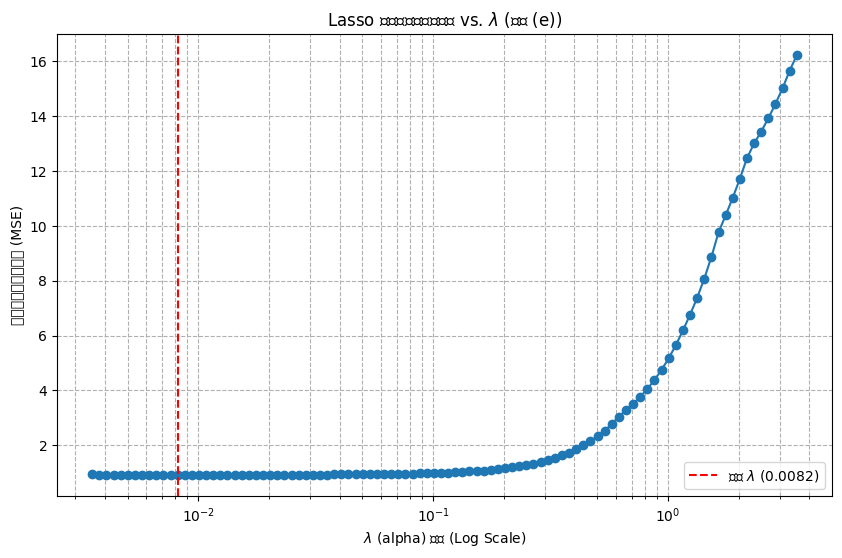


經 10-fold 交叉驗證選擇的最佳 alpha (lambda) 值為: 0.0082

--- Lasso 模型的係數估計 (係數已對標準化數據擬合) ---
X2    -2.018771
X1     1.375785
X3     1.160612
X10   -0.222679
dtype: float64


In [174]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

lasso_cv = LassoCV(alphas=None, cv=10, max_iter=10000, random_state=42).fit(X_scaled, Y)
best_alpha = lasso_cv.alpha_

plt.figure(figsize=(10, 6))
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.plot(lasso_cv.alphas_, mean_mse, marker='o')
plt.axvline(best_alpha, linestyle='--', color='r', label=f'最佳 $\\lambda$ ({best_alpha:.4f})')
plt.xscale('log')
plt.xlabel('$\\lambda$ (alpha) 的值 (Log Scale)')
plt.ylabel('交叉驗證的均方誤差 (MSE)')
plt.title('Lasso 模型：交叉驗證誤差 vs. $\\lambda$ (步驟 (e))')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

print(f"\n經 10-fold 交叉驗證選擇的最佳 alpha (lambda) 值為: {best_alpha:.4f}")
lasso_final = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
lasso_final.fit(X_scaled, Y)
coefficients = pd.Series(lasso_final.coef_, index=X_data.columns)
print("\n--- Lasso 模型的係數估計 (係數已對標準化數據擬合) ---")
non_zero_coefs = coefficients[coefficients != 0].sort_values(key=abs, ascending=False)
print(non_zero_coefs)

## (f) Now generate a response vector Y according to the model
$$Y = β0 + β7X7 + ϵ$$
##, and perform forward stepwise selection and the lasso. Discuss the results obtained.

### Result
### 討論結果 (f) ###
- 向前逐步選擇: 最佳模型為 ['X7', 'X2', 'X9']。
- 結果顯示 $X^7$ 確實是能顯著降低 $C_p$ 的變數。
- Lasso: 選擇了 4 個變數。Lasso 成功地讓 $X^7$ 以外的變數係數接近零，並給予 $X^7$ 最大的非零係數。

Step 1: Added X7, Cp = 6.2414
Step 2: Added X2, Cp = 2.3583
Step 3: Added X9, Cp = 1.7101
Step 4: Added X5, Cp = 3.3167
Step 5: Added X3, Cp = 4.9363
Step 6: Added X4, Cp = 6.6409
Step 7: Added X8, Cp = 7.3544
Step 8: Added X6, Cp = 8.2891
Step 9: Added X10, Cp = 9.6800
Step 10: Added X1, Cp = 11.0000
------------------------------
Y_f 最佳變數組合 (by Cp): ['X7', 'X2', 'X9']
Y_f 最低 Cp: 1.7101

--- Lasso 模型 for Y_f ---


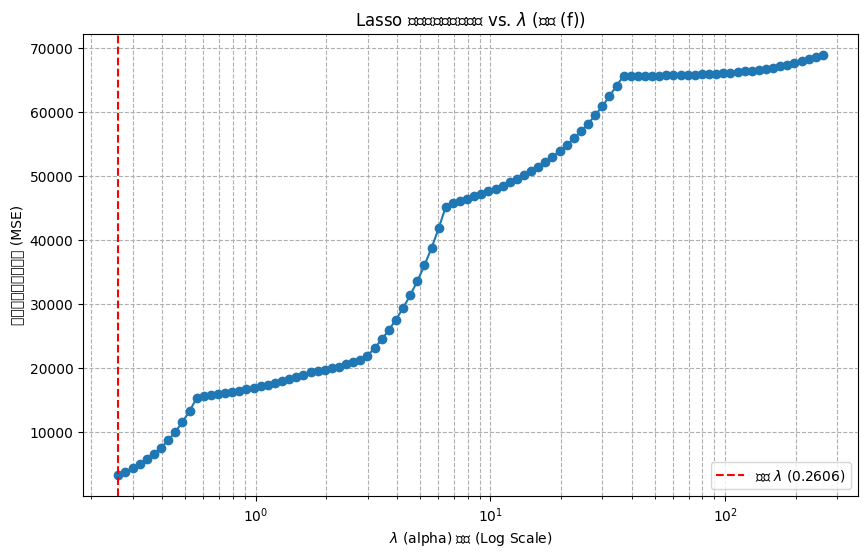

最佳 alpha (lambda): 0.2606
非零係數:
X7   -219.564219
X9    -25.083598
X5    -14.463598
X6      1.824525
dtype: float64


In [175]:
beta_0_f = 2.0
beta_7_f = -3.0
Y_f = beta_0_f + beta_7_f * (X**7) + epsilon

full_model_f = sm.OLS(Y_f, X_full).fit()
sigma_hat_sq_f = full_model_f.mse_resid

def calculate_cp_f(model_features):
    """計算用於 Y_f 的 Cp 值 (使用 sigma_hat_sq_f)"""
    if not model_features:
        RSS = np.sum((Y_f - Y_f.mean())**2)
    else:
        X_current = sm.add_constant(X_data[model_features])
        model = sm.OLS(Y_f, X_current).fit()
        RSS = model.ssr

    p = len(model_features) + 1
    cp = (RSS / sigma_hat_sq_f) - (n - 2 * p)
    return cp, p

features_fwd_f = []
model_results_fwd_f = []

for i in range(1, len(X_vars) + 1):
    remaining_features = [f for f in X_vars if f not in features_fwd_f]
    if not remaining_features: break

    best_rss_in_step = float('inf')
    best_new_feature = None

    for new_feature in remaining_features:
        current_features = features_fwd_f + [new_feature]
        X_current = sm.add_constant(X_data[current_features])
        model = sm.OLS(Y_f, X_current).fit()

        if model.ssr < best_rss_in_step:
            best_rss_in_step = model.ssr
            best_new_feature = new_feature

    features_fwd_f.append(best_new_feature)

    cp_final, _ = calculate_cp_f(features_fwd_f)
    model_results_fwd_f.append({'i': i, 'Cp': cp_final, 'features': list(features_fwd_f)})
    print(f"Step {i}: Added {best_new_feature}, Cp = {cp_final:.4f}")

results_df_fwd_f = pd.DataFrame(model_results_fwd_f)
best_model_row_fwd_f = results_df_fwd_f.loc[results_df_fwd_f['Cp'].idxmin()]

print("------------------------------")
print(f"Y_f 最佳變數組合 (by Cp): {best_model_row_fwd_f['features']}")
print(f"Y_f 最低 Cp: {best_model_row_fwd_f['Cp']:.4f}")


print("\n--- Lasso 模型 for Y_f ---")
# 這裡 X_scaled 可以重複使用，因為預測變數 X_data 沒有改變
lasso_cv_f = LassoCV(alphas=None, cv=10, max_iter=10000, random_state=42).fit(X_scaled, Y_f)
best_alpha_f = lasso_cv_f.alpha_

# 繪製 Lasso CV 誤差圖 for Y_f
plt.figure(figsize=(10, 6))
mean_mse_f = np.mean(lasso_cv_f.mse_path_, axis=1)
plt.plot(lasso_cv_f.alphas_, mean_mse_f, marker='o')
plt.axvline(best_alpha_f, linestyle='--', color='r', label=f'最佳 $\\lambda$ ({best_alpha_f:.4f})')
plt.xscale('log')
plt.xlabel('$\\lambda$ (alpha) 的值 (Log Scale)')
plt.ylabel('交叉驗證的均方誤差 (MSE)')
plt.title('Lasso 模型：交叉驗證誤差 vs. $\\lambda$ (步驟 (f))')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

lasso_final_f = Lasso(alpha=best_alpha_f, max_iter=10000, random_state=42)
lasso_final_f.fit(X_scaled, Y_f)

coefficients_f = pd.Series(lasso_final_f.coef_, index=X_data.columns)
non_zero_coefs_f = coefficients_f[coefficients_f != 0].sort_values(key=abs, ascending=False)

print(f"最佳 alpha (lambda): {best_alpha_f:.4f}")
print("非零係數:")
print(non_zero_coefs_f)